# LIGO: chirp-mass regression

Predict chirp mass in solar masses from two whitened detector channels. Whitening rescales frequency components using the detector noise spectrum. Chirp mass is the combination of the two source masses that governs the leading rise in gravitational-wave frequency. Each event is cropped to the 59–63 second window, giving 1,024 samples per channel. No per-event amplitude normalization is added. The small demo uses only the first released SNR 10–15 training/validation shards; it does not represent the full SNR distribution.

This is a **three-iteration workflow demo**, not a reproduction of the paper artifact or score. Model quality and Health PASS are not completion requirements. Validation scores feed back to the agent; this is not an unseen final test.

**Start here:** follow the [setup guide](https://github.com/yuema137/siderius-exp/tree/main/tutorials/paper/prepared), then open this copied notebook in your external project using its exp kernel. All code, comments and saved configuration are English.

The first pass is **Quick A → B → C**:
1. Quick A saves your settings and script, then reopens them to show what will run.
2. Quick B invokes that exact script. This uses paid APIs and your GPU.
3. Quick C reads real records and saves a score-versus-iteration plot. Stop here on your first pass.

Later sections are optional exercises: change parameters, create a new split, and launch that new saved experiment. They do not launch another search during Run All. With data and keys prepared, Run All performs the three steps above. Set `RUN_QUICK_DEMO=False` to skip API/GPU work; Quick A will still save inputs.
**LLM configuration for this demo:** a new project saves `llm/agents.json` with OpenAI `gpt-6-luna` and `medium` reasoning for every workflow route, plus the built-in `native-timing-v1` planner. Inspect that file before running; it is independent of paper experiment routing. Iterations, training budgets and repair attempts remain separate experiment controls. This profile has offline checks, not yet a successful live Luna qualification. The pictures and scores already displayed here come from earlier recorded runs with their original models.

## Hardware before Run All

Training needs one supported NVIDIA GPU, the paired CUDA environment and working driver memory accounting. CPU machines can inspect data or plot existing results, but cannot run this training demo. AMD/ROCm remains experimental and currently lacks the accounting required by this route; Intel GPU training is unsupported. Select one device with `CUDA_VISIBLE_DEVICES` before starting Jupyter.

The shipped short demo sets a **8 GiB VRAM allowance**. The GPU must have greater physical capacity, and its current occupied memory plus the larger saved Trial/Formal allowance must fit within the device/deployment limit. This is a configured allowance, not a measured model minimum. Lowering it does not make every generated model fit.

The complete source manifest totals about 2.36 GB; selected-row preparation can transfer less. Keep additional space for staged arrays and outputs. No universal training host-RAM minimum has been qualified. The hardware report shows host RAM and output-filesystem space as observations, not a guarantee of sufficient memory for this workload.

**Check without paying or training:** First run Quick A to save the JSON; this command checks that quick-demo file, not the initial template.

```bash
cd /absolute/path/siderius-exp
.venv/bin/python -m tutorials.shared.hardware \
  --experiment "$TUTORIAL_HOME/experiments/ligo_quick-demo-001.json"
```

This hardware-only command needs no API key and creates no run workspace; it queries the GPU and runs a tiny kernel. It does not replace task/data/configuration review. Fresh Run All launches repeat the GPU check automatically before provider calls. A pass does not reserve memory or prove that a future generated model fits; native measurement and monitoring still apply. Set `RUN_QUICK_DEMO=False` for a CPU/offline walkthrough. See the [hardware setup guide](https://github.com/yuema137/siderius-exp/blob/main/tutorials/shared/hardware/README.md) for limits and corrective steps.


## See the data before running anything

**Recorded training example.** This image is included for GitHub browsing; it does not require a kernel, credentials, or a GPU. It was read from the recorded training dataset, not synthesized for this illustration or produced by a trained model.

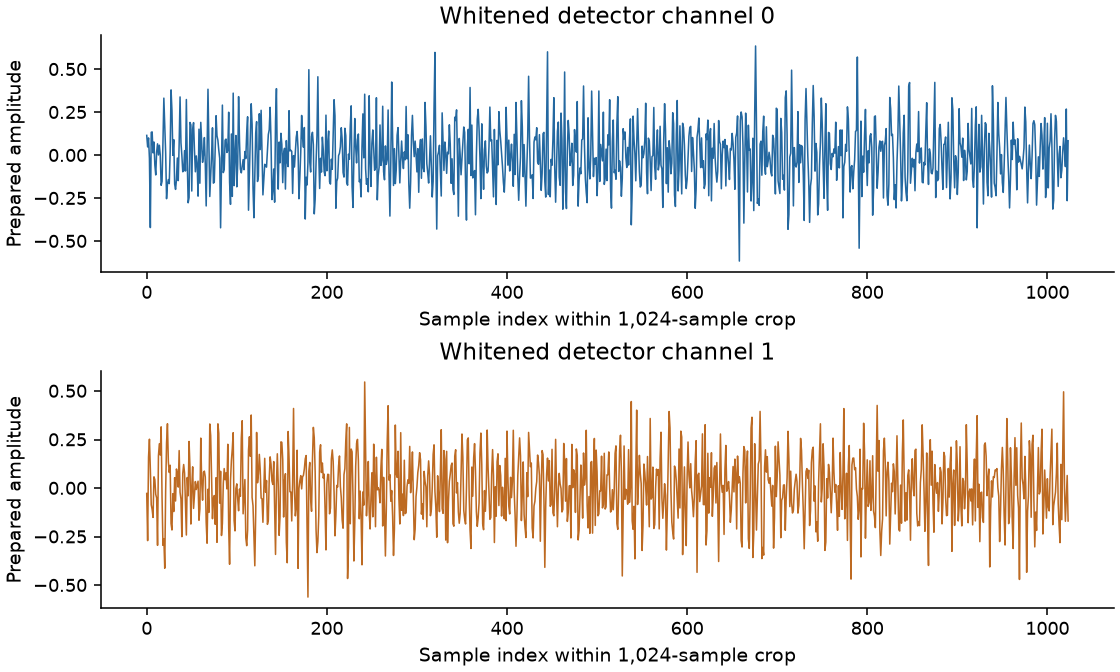

Training event 0: input [2, 1024], target [1] = 1.47618 solar masses (chirp mass). Both detector channels belong to the same event. These are the prepared whitened/cropped inputs, not raw detector strain. Files: training/inputs.npy [N, C, L] and training/targets.npy [N, 1].

After Quick A, the **Inspect your own training data** cell reads the files selected by your saved experiment. Change `PREVIEW_ROW` there to view another training observation.


## A completed example: what the run produced

**Archived example, not your current run.** Recorded on 2026-09-30 on an RTX 5090: 3 iterations, 29.2 minutes including agent calls and retries, launcher exit code 0. Your own result appears in Quick C only after you configure the environment and run Quick B (or select an existing completed run). This reference image stays here when you rerun the notebook.

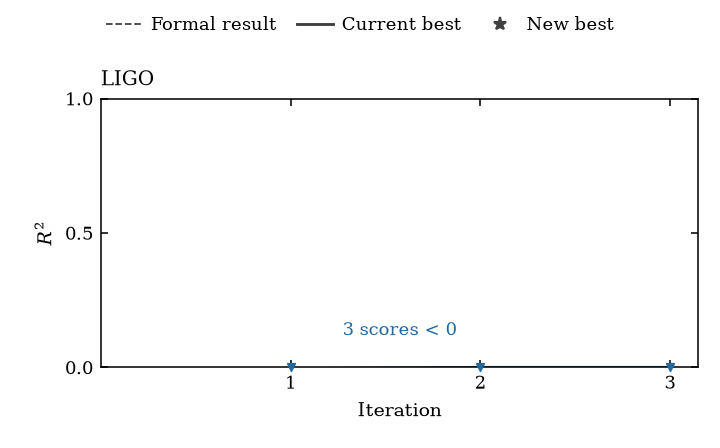

| Iteration | Formal R² | Recorded status |
|---|---:|---|
| 1 | -0.0048093648 | `success` |
| 2 | -3.7054115e-06 | `success` |
| 3 | -0.00094685539 | `success` |

All three scored Formal attempts completed, but their R² values are negative: they performed worse than the validation-mean baseline. This task explicitly declares no Health checks; filled markers mean successful scored execution, not Health PASS.

The dashed line follows scored Formal attempts; the solid line tracks the highest recorded score, including invalid attempts. Hollow markers indicate failed checks or execution. For R², negative values use downward boundary markers at zero; the table retains the actual values. Five unscored records are retained in the CSV, not drawn as zero.

[Example scores and provenance](https://github.com/yuema137/siderius-exp/tree/main/tutorials/paper/examples) include `ligo-progress.csv` and `ligo-example.json`. These are workflow demos, not paper artifacts or promised model quality.


In [ ]:
import json
import os
import shlex
import sys
from pathlib import Path

project_env = os.environ.get("TUTORIAL_HOME")
if not project_env:
    raise RuntimeError(
        "Missing TUTORIAL_HOME. In your terminal, export TUTORIAL_HOME=/absolute/path/to/your/tutorial-project, "
        "then restart Jupyter from that terminal. Use the external project created in the README setup step."
    )
PROJECT = Path(project_env).expanduser().resolve()
if not (PROJECT / "project.json").is_file():
    raise RuntimeError(
        f"Missing {PROJECT / 'project.json'}. Point TUTORIAL_HOME at your initialized external project, "
        "or complete the README's create-project command first. Do not use the source repo as your project."
    )
binding = json.loads((PROJECT / "project.json").read_text())
EXP, INFRA = Path(binding["exp_checkout"]), Path(binding["infra_checkout"])
if Path(sys.prefix).resolve() != (EXP / ".venv").resolve():
    raise RuntimeError(
        f"Wrong notebook kernel: {sys.executable}. Select the kernel installed from {EXP / '.venv/bin/python'}. "
        f"If missing, run: cd {shlex.quote(str(EXP))} && uv sync --group dev --group tutorial --frozen; "
        "then register/select that environment's Jupyter kernel as shown in the README."
    )
import importlib.util

missing_modules = [
    name
    for name in (
        "pydantic",
        "yaml",
        "numpy",
        "h5py",
        "torch",
        "workflows",
        "matplotlib",
    )
    if importlib.util.find_spec(name) is None
]
if missing_modules:
    raise RuntimeError(
        f"Missing Python modules: {', '.join(missing_modules)}. "
        f"Run: cd {shlex.quote(str(EXP))} && uv sync --group dev --group tutorial --frozen; then restart this kernel."
    )
sys.dont_write_bytecode = True
os.chdir(EXP)  # import installed tools; edited files always use absolute project paths

## Quick A — save and inspect the files you will run

One **iteration** is one candidate-model search cycle. **Trial** tries training settings on a selected subset; **Formal** trains/evaluates the chosen settings on its selected population. An **epoch** is one pass over the rows selected for that training epoch. The time budget can stop training before its epoch ceiling.

Start with the prepared **512 training / 1,000 validation** event demo. The task also fixes **100 validation events** for epoch-loss monitoring. Trial uses half of each population by default; Formal uses the whole small population. These are fractions of your demo, not fractions of the full released dataset.

```text
your-project/
  tasks/ligo-demo-001/compositions/regression.yaml  # task entry
  tasks/ligo-demo-001/declared/prepared.json        # populations + data identity
  data/demo-001/manifest.json                       # exact row membership + hashes
  experiments/ligo_quick-demo-001.json            # settings saved below
  llm/agents.json                                   # provider/model routing, no keys
  llm/literature_review.yaml                        # literature search settings
  scripts/run-ligo_quick-demo-001.sh               # runs that experiment JSON
  runs/ligo_quick-demo-001/                        # native results after launch
  plots/ligo_quick-demo-001/                       # PNG, SVG and CSV after plotting
```

The notebook prints **absolute paths** below. Open these files to review your changes; changing an in-memory variable alone does not change a saved experiment. Keys are inherited from the terminal that started Jupyter. Human advice and Data Analysis are disabled; Literature Review is enabled. The `advice/README.txt` file explains that no advice file is consumed.

Use a new `DEMO_NAME` when changing saved parameters, so previous inputs and results remain intact.

If you prepared a custom named dataset, change `DATA_NAME` below. It selects both `tasks/<task>-<name>/compositions/regression.yaml` and `data/<name>/`; use a fresh `DEMO_NAME` too. The checklist reports the actual row counts, which may differ from the default example above.

The default uses 512 training events, batch size 1 and full per-epoch exposure
inside the selected scope. A 50% Trial has 256 batches per epoch. The 1,000-event
validation pool fixes 100 events for epoch-loss monitoring; four epochs provide
up to 400 validation observations. These counts give the native runtime verifier
more real observations; it still decides whether timings are stable enough.

The large validation-to-training ratio serves timing measurement in this short
demo, not a recommended scientific split. Reducing data or fractions, increasing
batch size, or reducing epochs can leave too little evidence and cause rejection
before scoring. A custom 64/20 dataset is for offline file-editing practice.

Project8 retains a partial final training batch. LIGO keeps native `drop_last`
behavior, which can discard a partial tail after a custom batch-size change;
batch size 1 has no partial tail. No Health threshold, training allowance or
runtime verification rule is relaxed.


Use one visible logical GPU. `gpu=None` adds no name requirement; a string requires a matching name. NVIDIA models have no name whitelist. To select one card, set `CUDA_VISIBLE_DEVICES` before starting Jupyter.

Keep both VRAM budgets below device capacity. Launch checks driver queries and a small kernel, which does not prove model fit.

AMD/ROCm is experimental and untested; required driver accounting is unavailable. Intel GPU and CPU training are unsupported. Follow the [hardware setup](https://github.com/yuema137/siderius-exp/blob/main/tutorials/shared/hardware/README.md) for the frozen installation and required checks. Use a new `DEMO_NAME` if you already saved different settings.


In [ ]:
from IPython.display import Markdown, display

from tutorials.paper.launch_review import launch_review
from tutorials.paper.quick_demo import prepare_demo, run_demo

DATA_NAME = "demo-001"  # The name passed to the data preparation helper.
DEMO_NAME = "quick-demo-001"
RUN_QUICK_DEMO = True  # Paid API calls and GPU training in Quick B.
QUICK_SETTINGS = {
    "gpu": None,  # Automatic name selection; a string adds an expected-name check.
    "composition": PROJECT
    / "tasks"
    / f"ligo-{DATA_NAME}"
    / "compositions/regression.yaml",
    "data_dir": PROJECT / "data" / DATA_NAME,
    "iterations": 3,
    "epochs": 4,
    "batch_size": 1,
    "trial_minutes": 2.0,
    "formal_minutes": 5.0,
    "vram_gib": 8.0,
    "trial_train_fraction": 0.5,
    "trial_val_fraction": 0.5,
    "formal_train_fraction": 1.0,
    "formal_val_fraction": 1.0,
}
demo = prepare_demo(PROJECT, "ligo", name=DEMO_NAME, settings=QUICK_SETTINGS)
display(Markdown(launch_review(demo.experiment, demo.script, task="ligo")))

### Inspect your own training data

This cell reads **`demo.experiment`**, the JSON saved and reviewed above, then opens one observation from its training data. It does not download, train, call an API, or read a final test. Change `PREVIEW_ROW` to select another training row. The plot is generated from your files; the archived examples above remain labeled reference images.


In [ ]:
import matplotlib.pyplot as plt
from tutorials.paper.data_preview import plot_training_example

PREVIEW_ROW = 0
data_figure, data_description = plot_training_example(
    demo.experiment, task="ligo", row=PREVIEW_ROW
)
print(data_description)
display(data_figure)
plt.close(data_figure)


## Quick B — run the saved shell script once

Read the checklist above before running this cell. It displays the exact file passed to `bash` and the exact experiment JSON the script reads. The notebook calls that same script with `--launch`; the script owns setup checks and native workflow execution.

Do **not** also paste the launch command into another terminal for the same run. Open the printed console-log path to see progress. Training time budgets are per attempt; LLM work and setup add time and API charges. Three iterations can still take many minutes. A failed model is a possible result, not a reason to change validity rules or extend the demo.

A completed, unchanged Run All reuses its result receipt without another search. For changed inputs, choose a new name. Interrupted runs require inspecting the log and stopping any active process before starting a different named run.

The per-attempt training budgets do not bound notebook duration. Each iteration also calls LLMs and searches literature. Provider latency and literature-service rate limits can add several minutes per iteration; the console log shows progress and retries. With the defaults shown here, our RTX 5090 runs completed all three iterations in about 32 minutes for Project8 and 29 minutes for LIGO, including service waits and native retries. These are observed examples, not duration guarantees. Both runs produced negative R² scores; the demo teaches execution and inspection rather than scientific performance.


In [ ]:
if RUN_QUICK_DEMO:
    result = run_demo(demo)
    print(result)
else:
    print("Execution skipped; saved input files remain available for inspection.")

## Quick C — read real scores and save the paper-style plot

The dashed line shows Formal scores and the solid line shows the current best. This task explicitly declares **no task-specific Health checks**. Filled markers therefore mean a successful scored execution under that declaration, **not Health PASS**; hollow markers denote failed scored attempts. No score is invented for an unscored attempt. Negative R² values use boundary triangles and retain their actual values in the CSV.

To plot another run, set `PLOT_EXPERIMENT` to its saved experiment JSON and execute only this cell. That JSON gives the result workspace and matching task declaration. The helper checks the task's explicit no-Health declaration. It does not rerun training.

In [ ]:
import matplotlib.pyplot as plt

from tutorials.paper.prepared.review import plot_demo
from tutorials.paper.prepared.runner import PreparedExperiment

PLOT_EXPERIMENT = (
    demo.experiment
)  # Or Path("/your/project/experiments/another-run.json")
plot_settings = PreparedExperiment.model_validate_json(PLOT_EXPERIMENT.read_text())
PLOT_OUTPUT = PROJECT / "plots" / plot_settings.workspace.name
if plot_settings.workspace.is_dir():
    figure = plot_demo(PLOT_EXPERIMENT, PLOT_OUTPUT)
    display(figure)
    plt.close(figure)
    for name in (
        "score-versus-iteration.png",
        "score-versus-iteration.svg",
        "score-versus-iteration.csv",
    ):
        print(PLOT_OUTPUT / name)
else:
    print("No run workspace yet. Run Quick B or select a completed experiment JSON.")

## Optional exercise 1 — understand the task/experiment boundary

The **task package** says what an event means, which rows belong to training/validation, what input/output shapes a model must use, and how R²/RMSE are scored. Its entry is `compositions/regression.yaml`. The **experiment JSON** chooses that task and data pair, model routing, hardware, fractions, budgets and a fresh output workspace. The fixed workflow executes a Trial then a Formal stage per proposed model.

Changing `iterations`, `epochs`, a fraction or a budget changes the experiment. Changing split membership creates a new task **and matching prepared data**. Never hand-edit a data hash or population count to make another array fit. The data helper creates consistent declarations and hashes together.

The following cell reopens actual files; it does not show an unsaved Python object.

In [ ]:
import yaml

from tutorials.paper.prepared.runner import PreparedExperiment

saved = PreparedExperiment.model_validate_json(demo.experiment.read_text())
entry = yaml.safe_load(saved.composition.read_text())
declaration = saved.composition.parent.parent / "declared/prepared.json"
manifest = saved.data_dir / "manifest.json"
print("TASK ENTRY:", saved.composition)
print(saved.composition.read_text())
print("DATA DECLARATION:", declaration)
print(declaration.read_text())
print("EXPERIMENT:", demo.experiment)
print(demo.experiment.read_text())
if manifest.is_file():
    evidence = json.loads(manifest.read_text())
    print(
        "First row identities:",
        {s: rows[:5] for s, rows in evidence["row_identities"].items()},
    )

## Optional exercise 2 — change a few parameters

| Setting | What it changes | Example |
|---|---|---|
| `iterations` | Number of model-search cycles | 3 → 4 |
| `epochs` | Maximum epochs per attempt, subject to time budget | 4 → 5 |
| `trial_train_fraction` | Available training population in Trial | 0.5 → 0.75: 256 → 384 of 512 events |
| `formal_train_fraction` | Available training population in Formal | 1.0 → 0.5: 512 → 256 events |
| `trial_val_fraction`, `formal_val_fraction` | Scoring rows within validation | 0.5 means 500 of 1,000 events |
| `trial_minutes`, `formal_minutes` | Per-attempt training allowances | 2 / 5 minutes |
| `vram_gib` | Default model memory budget for both stages | 8 GiB, below physical GPU capacity |
| `trial_vram_gib`, `formal_vram_gib` | Optional stage-specific overrides | 6 / 8 GiB |
| `batch_size` | Examples per training step in both stages; default 1 increases the number of timing observations | Increase only with a sufficiently large training scope |
| `gpu` | Optional expected GPU name | `None` for automatic selection; a string requires a match |

Both stages use every row of their selected training scope per epoch. The demo fixes per-epoch exposure to 1.0 so a tiny pool is not sampled down a second time. Epoch-loss validation is always the task's fixed 10% snapshot; changing scoring fractions does not resize it. Validation choices affect feedback and comparability.

Use the device selected in Quick A under the [shared hardware instructions](https://github.com/yuema137/siderius-exp/blob/main/tutorials/shared/hardware/README.md). There is no separate coding-agent filesystem sandbox in this fixed-workflow demo; generated model code runs under your account through the native runner.

Set `SAVE_VARIANT=True` once to save a new experiment and script. This cell only saves and previews; launch the exact printed command later if wanted.

Reducing a training fraction or increasing batch_size can leave too few batches for native timing verification. A 64/20 dataset is useful to practice file editing offline; it is not a validated runnable setting. Keep the default settings for the first real run.

Full per-epoch exposure selects the entire chosen scope before batching. Project8 retains a partial final batch (`drop_last=False`). LIGO keeps its native batching policy, so an incomplete final batch may be dropped; the default 256/512 training scopes divide evenly by batch size 1.

In [ ]:
SAVE_VARIANT = False
if SAVE_VARIANT:
    changed = {
        **QUICK_SETTINGS,
        "iterations": 4,
        "trial_train_fraction": 0.75,
        "formal_train_fraction": 0.5,
        "trial_vram_gib": 6.0,
        "formal_vram_gib": 8.0,
    }
    variant = prepare_demo(PROJECT, "ligo", name="changed-scope-001", settings=changed)
    display(Markdown(launch_review(variant.experiment, variant.script, task="ligo")))
else:
    print("No additional experiment saved. The quick demo remains independent.")

## Optional exercise 3 — create a different train/validation split

Fractions do not move events between splits. To change membership, create a new named task/data pair from the task/data pair selected in Quick A. The cell reads its saved declaration counts, so a custom 64/20 subset remains 64/20 before pooling. This exercise pools only the selected training/validation events, shuffles event identities with a fixed seed and assigns a new validation share. It never reads the released test data. Validation size is rounded down to a multiple of 10, with a 20-event minimum, so the fixed 10% loss snapshot remains exact.

This is a new demo protocol. Its score cannot be compared directly with the previous split or the paper. The manifest preserves original row IDs, so you can verify that no event belongs to both new populations. `seed` affects this optional re-split and the loss snapshot; it does not change the deterministic source subset chosen for the initial demo.

Set `SAVE_SPLIT=True` once. The cell prints the new task, data, experiment, script and output paths. It does not launch another search.

The example assigns 66% to validation: from the default 1,512 events it creates 522 training and 990 validation events, including 99 fixed epoch-loss events. This preserves a larger number of timing observations; the runtime verifier still decides whether they are sufficient. For a custom source population, inspect the printed counts before launching; the same percentage does not guarantee enough batches.


In [ ]:
SAVE_SPLIT = False
if SAVE_SPLIT:
    from tutorials.paper.prepared.data import DatasetRecipe, prepare

    current_counts = json.loads(
        (saved.composition.parent.parent / "declared/prepared.json").read_text()
    )
    recipe = DatasetRecipe(
        task="ligo",
        name="resplit-seed7",
        seed=7,
        resplit_validation_fraction=0.66,
        train_rows=current_counts["train_count"],
        validation_rows=current_counts["validation_count"],
    )
    task_entry = prepare(PROJECT, recipe, source=saved.data_dir)
    changed = {
        **QUICK_SETTINGS,
        "composition": task_entry,
        "data_dir": PROJECT / "data/resplit-seed7",
    }
    split_demo = prepare_demo(PROJECT, "ligo", name="resplit-001", settings=changed)
    split_manifest = json.loads(
        (PROJECT / "data/resplit-seed7/manifest.json").read_text()
    )
    groups = split_manifest["row_identities"]
    assert not set(groups["train"]) & set(groups["validation"])
    print("New membership:", {key: len(value) for key, value in groups.items()})
    display(
        Markdown(launch_review(split_demo.experiment, split_demo.script, task="ligo"))
    )
else:
    print("No new split files saved. Original task and data remain intact.")

## What to do after a run

Open the printed PNG/SVG or CSV under `plots/`. Native records and generated models live under the experiment's `workspace`; the console log and run receipt sit next to it under `runs/`. Check these files before interpreting a missing point. A setup failure, an unscored model and a low but recorded R² are different outcomes.

Keep the saved task/data pair and experiment JSON with your results. Change `DEMO_NAME` for a new run and review Quick A again. Never place API keys in notebooks, configuration, logs or Git. This demo has no independent final-test step and makes no paper-reproduction claim.